# Imports

In [19]:
import numpy as np
import matplotlib.pyplot as plt

import pylops
import time as _time

from scipy.ndimage        import shift   as nd_shift
from scipy.signal         import hilbert as sp_hilbert
from scipy.signal.windows import tukey

# Functions

In [20]:
# -- Vectorised point-scatterer B-scan ----------------------------------------
def point_bscan(x_sc, z_sc, x_rec, t_arr, v, fc):
    r   = np.sqrt((x_rec - x_sc)**2 + z_sc**2)
    twt = 2.0 * r / v
    amp = 1.0 / np.sqrt(r)
    u   = np.pi * fc * (t_arr[:, None] - twt[None, :])
    return amp[None, :] * (1.0 - 2*u**2) * np.exp(-u**2)

# -- Z-direction Riesz transform ----------------------------------------------
def riesz_z(W):
    nz, nx = W.shape
    KX, KZ = np.meshgrid(np.fft.fftfreq(nx), np.fft.fftfreq(nz))
    K = np.sqrt(KX**2 + KZ**2);  K[0, 0] = 1.0
    return np.real(np.fft.ifft2((-1j * KZ / K) * np.fft.fft2(W)))

In [21]:

def gazdag_migration(data, x, t, z, vel):
    """
    Gazdag (1978) phase-shift migration for zero-offset post-stack data.

    data : (n_t, n_x)  B-scan, time axis first, t0-shifted
    x, t : 1-D arrays [m, ns]
    z    : 1-D depth axis [m], uniformly spaced from 0
    vel  : full medium velocity [m/ns]; v_mig = vel/2 used internally

    Returns image (n_z, n_x), peak-normalised to +-1.
    """
    import numpy as np
    n_t, n_x = data.shape
    dt    = float(t[1] - t[0])
    dx    = float(x[1] - x[0])
    dz    = float(z[1] - z[0])
    v_mig = vel / 2.0

    # Spatial cosine taper (5%) + 100% zero-pad each side
    n_xtap  = max(3, int(0.05 * n_x))
    pad     = n_x
    sp_tap  = pylops.utils.tapers.taper2d(n_t, n_x, n_xtap)   # (n_x, n_t)
    data_sp = np.pad(
        data.T * sp_tap,            # (n_x, n_t)
        ((pad, pad), (0, 0)),
        mode='constant'
    )                               # (nx_pad, n_t)
    nx_pad = n_x + 2 * pad

    # f-kx evanescent filter
    D_fk       = np.fft.fft(np.fft.rfft(data_sp, axis=1), axis=0)
    freq_arr   = np.fft.rfftfreq(n_t, dt)
    kx_arr     = np.fft.fftfreq(nx_pad, dx)
    evanescent = np.abs(kx_arr[:, None]) > np.abs(freq_arr[None, :]) / v_mig
    D_fk[evanescent] = 0.0
    data_sp = np.real(np.fft.irfft(np.fft.ifft(D_fk, axis=0), n=n_t, axis=1))

    print(f'  nx={n_x} -> nx_pad={nx_pad},  evanescent: '
          f'{evanescent.sum()}/{evanescent.size} ({100*evanescent.mean():.1f}%)')

    # PhaseShift depth loop: downward continuation + t=0 imaging condition
    freq  = np.fft.rfftfreq(n_t, dt)
    kx    = np.fft.fftshift(np.fft.fftfreq(nx_pad, dx))
    Pop   = pylops.waveeqprocessing.PhaseShift(v_mig, dz, n_t, freq, kx)
    field = data_sp.T.ravel()

    image = np.zeros((len(z), n_x))
    for iz in range(len(z)):
        image[iz] = np.real(field.reshape(n_t, nx_pad)[0, pad:-pad])
        if iz < len(z) - 1:
            field = Pop.H * field

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)


In [22]:


def estimate_shift_2d(base, mon, dz_g, dx_g, kz_cent):
    """
    Fit a 2D phase plane phi(kz,kx) = kz*dz + kx*dx + c to the cross-spectrum.
    
    Updates:
    - Uses a Tukey window to preserve core wavelet amplitudes.
    - Dynamically bounds the fitting to where the cross-spectrum energy is 
      strong, preventing phase-wrapping errors safely.
    """
    Nz, Nx = base.shape
    
    # 1. Compute 2D wavenumber axes
    kz_ax = np.fft.fftfreq(Nz, d=dz_g) * 2 * np.pi
    kx_ax = np.fft.fftfreq(Nx, d=dx_g) * 2 * np.pi
    KZ, KX = np.meshgrid(kz_ax, kx_ax, indexing='ij')

    # 2. Apply Tukey window (tapers outer 15%, leaves inner 85% pristine)
    taper = np.outer(tukey(Nz, alpha=0.15), tukey(Nx, alpha=0.15))
    
    # 3. Compute Cross-Spectrum
    base_fft = np.fft.fft2(base * taper)
    mon_fft  = np.fft.fft2(mon * taper)
    XS       = base_fft * np.conj(mon_fft)

    # 4. Extract weights (magnitude) and phase
    w   = np.abs(XS)
    phi = np.angle(XS)

    # 5. Dynamic Band Limit Mask
    # Limits evaluation to a stable band around center frequencies to avoid 
    # phase wrapping, while filtering out low-energy noise floors (<10% peak)
    band = (np.abs(KZ) < 1.4 * kz_cent) & (np.abs(KX) < 1.4 * kz_cent)
    mask = (w > 0.10 * w.max()) & band & ((np.abs(KZ) + np.abs(KX)) > 0)

    # 6. Linear Regression (Weighted Least Squares)
    A = np.column_stack([KZ[mask], KX[mask], np.ones(mask.sum())])
    W = w[mask]  # Amplitude weights ensure reliable bins dominate the fit
    
    # Solve system: (A * W) * c = (phi * W)
    c = np.linalg.lstsq(A * W[:, None], phi[mask] * W, rcond=None)[0]
    
    return c[0], c[1], XS, kz_ax, kx_ax

# Tertiary variables

In [23]:
# -- Acquisition --------------------------------------------------------------
dx_b   = 0.005 / 4
n_x_b  = 160 * 4
x_b    = np.arange(n_x_b) * dx_b       # 0 -- 0.795 m profile
x_sc0  = x_b.mean()

dt_b   = 0.004
n_t_b  = 1300                           # t_max = 5.196 ns > TWT(0.30 m) = 3.57 ns
t_b    = np.arange(n_t_b) * dt_b

z_sc   = 0.30
z_mig  = np.arange(0, 0.42, dx_b)      # 84 depth steps

In [24]:
v_ice  = 0.168        # m/ns
f_c    = 1.5          # GHz
lam    = v_ice / f_c  # wavelength in ice [m]

lambda      = 112.00 mm
vert shift  = 0.125 x lambda = 14.00 mm  (11.2 samples)
Baseline:   x = 399.4 mm,  z = 300.0 mm
Monitor:    x = 399.4 mm,  z = 314.0 mm

Synthesising B-scans...

Migrating baseline...
  nx=640 -> nx_pad=1920,  evanescent: 168695/1249920 (13.5%)
  done in 38.4 s

Migrating monitor...
  nx=640 -> nx_pad=1920,  evanescent: 168695/1249920 (13.5%)
  done in 37.9 s

Amplitude mask (8% of peak):
  baseline: 97.9%  monitor: 97.7%  delta: 98.3%


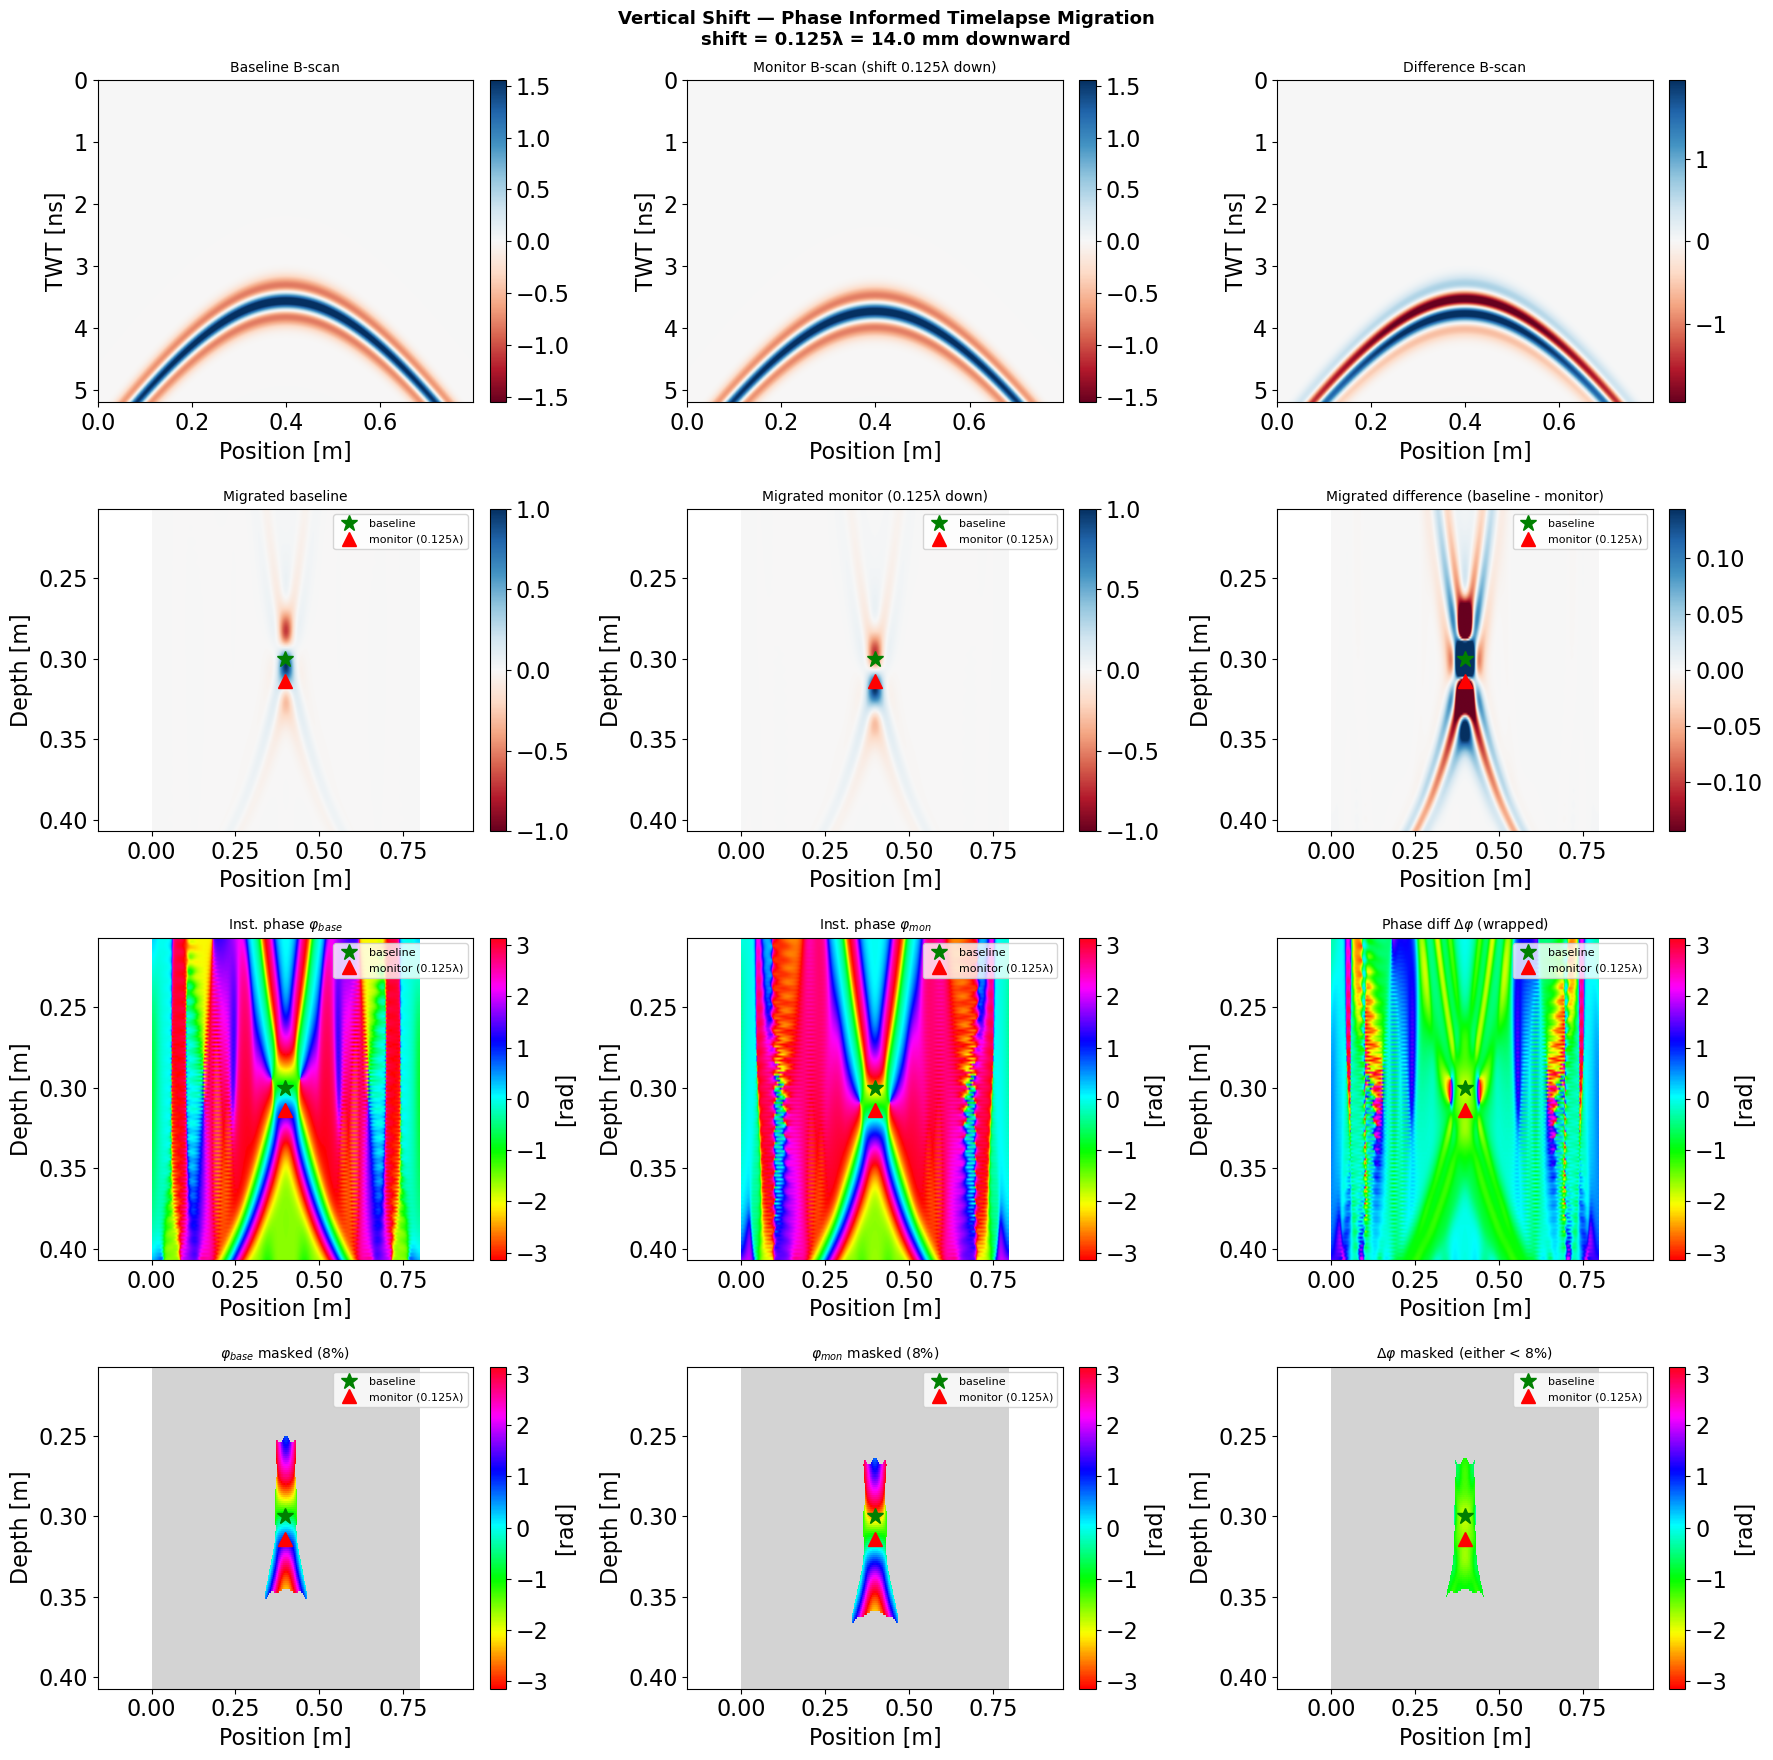

In [25]:
# =============================================================================
# Vertical Shift — Phase Informed Timelapse Migration
#
# Scatterer moves downward by dz_shift = shift_frac_v * lam.
# =============================================================================

# ── Parameters ───────────────────────────────────────────────────────────────
# v_ice, f_c, lam, x_b, t_b, z_mig, dx_b, x_sc0, z_sc  from earlier cells
dz_b = float(z_mig[1] - z_mig[0])

shift_frac_v = 1/8          # vertical shift as fraction of wavelength  <-- tune
dz_shift     = shift_frac_v * lam
z_sc_mon_v   = z_sc + dz_shift   # monitor scatterer depth

print(f"lambda      = {lam*1e3:.2f} mm")
print(f"vert shift  = {shift_frac_v} x lambda = {dz_shift*1e3:.2f} mm  ({dz_shift/dz_b:.1f} samples)")
print(f"Baseline:   x = {x_sc0*1e3:.1f} mm,  z = {z_sc*1e3:.1f} mm")
print(f"Monitor:    x = {x_sc0*1e3:.1f} mm,  z = {z_sc_mon_v*1e3:.1f} mm")

# ── 1. Synthesise B-scans ─────────────────────────────────────────────────────
print("\nSynthesising B-scans...")
B_v_base = point_bscan(x_sc0, z_sc,       x_b, t_b, v_ice, f_c)
B_v_mon  = point_bscan(x_sc0, z_sc_mon_v, x_b, t_b, v_ice, f_c)

# ── 2. Migrate both ───────────────────────────────────────────────────────────
print("\nMigrating baseline...")
t0 = _time.time()
mig_v_base = gazdag_migration(B_v_base, x_b, t_b, z_mig, v_ice)
print(f"  done in {_time.time()-t0:.1f} s")

print("\nMigrating monitor...")
t0 = _time.time()
mig_v_mon  = gazdag_migration(B_v_mon,  x_b, t_b, z_mig, v_ice)
print(f"  done in {_time.time()-t0:.1f} s")

# ── 3. Migrated difference ────────────────────────────────────────────────────
mig_v_diff = mig_v_base - mig_v_mon

# ── 4. Instantaneous amplitude & phase (Riesz-z) ─────────────────────────────
R_v_base = riesz_z(mig_v_base)
R_v_mon  = riesz_z(mig_v_mon)

A_v_base = np.sqrt(mig_v_base**2 + R_v_base**2)
A_v_mon  = np.sqrt(mig_v_mon**2  + R_v_mon**2)

phi_v_base  = np.arctan2(R_v_base, mig_v_base)
phi_v_mon   = np.arctan2(R_v_mon,  mig_v_mon)
phi_v_delta = np.angle(np.exp(1j * (phi_v_mon - phi_v_base)))

# ── 5. Amplitude-masked phase images ─────────────────────────────────────────
thresh_frac_v = 0.08

mask_v_base  = A_v_base < thresh_frac_v * A_v_base.max()
mask_v_mon   = A_v_mon  < thresh_frac_v * A_v_mon.max()
mask_v_delta = mask_v_base | mask_v_mon

phi_v_base_msk  = np.where(mask_v_base,  np.nan, phi_v_base)
phi_v_mon_msk   = np.where(mask_v_mon,   np.nan, phi_v_mon)
phi_v_delta_msk = np.where(mask_v_delta, np.nan, phi_v_delta)

print(f"\nAmplitude mask ({thresh_frac_v*100:.0f}% of peak):")
print(f"  baseline: {mask_v_base.mean()*100:.1f}%  monitor: {mask_v_mon.mean()*100:.1f}%  delta: {mask_v_delta.mean()*100:.1f}%")

# ── 6. QC display (4 x 3) ────────────────────────────────────────────────────
ext_b   = [x_b[0], x_b[-1], t_b[-1], t_b[0]]
ext_mig = [x_b[0], x_b[-1], z_mig[-1], z_mig[0]]

x_mid_v = x_sc0
z_mid_v = 0.5 * (z_sc + z_sc_mon_v)
x_lo_v  = x_mid_v - 5 * lam;  x_hi_v = x_mid_v + 5 * lam
z_lo_v  = z_mid_v - 0.10;     z_hi_v = z_mid_v + 0.10

def mig_zoom_v(ax):
    ax.set_xlim(x_lo_v, x_hi_v);  ax.set_ylim(z_hi_v, z_lo_v)
    ax.plot(x_sc0, z_sc,       'g*', ms=12, zorder=7, label='baseline')
    ax.plot(x_sc0, z_sc_mon_v, 'r^', ms=10, zorder=7, label=f'monitor ({shift_frac_v}\u03bb)')

clip_b_v   = np.percentile(np.abs(B_v_base), 99)
clip_diff_v = np.percentile(np.abs(mig_v_diff), 99)
hsv_cmap_v  = plt.get_cmap('hsv').copy();  hsv_cmap_v.set_bad('lightgrey')

fig, axes = plt.subplots(4, 3, figsize=(18, 18))
fig.suptitle(
    f"Vertical Shift — Phase Informed Timelapse Migration\n"
    f"shift = {shift_frac_v}\u03bb = {dz_shift*1e3:.1f} mm downward",
    fontsize=13, fontweight='bold',
)

# Row 0: B-scans
for ax, data, title in [
    (axes[0,0], B_v_base, "Baseline B-scan"),
    (axes[0,1], B_v_mon,  f"Monitor B-scan (shift {shift_frac_v}\u03bb down)"),
]:
    im = ax.imshow(data, aspect='auto', origin='upper', extent=ext_b,
                   cmap='RdBu', vmin=-clip_b_v, vmax=clip_b_v, interpolation='bilinear')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Position [m]");  ax.set_ylabel("TWT [ns]")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

B_v_diff = B_v_mon - B_v_base
im = axes[0,2].imshow(B_v_diff, aspect='auto', origin='upper', extent=ext_b,
                       cmap='RdBu', vmin=-np.percentile(np.abs(B_v_diff),99),
                       vmax=np.percentile(np.abs(B_v_diff),99), interpolation='bilinear')
axes[0,2].set_title("Difference B-scan", fontsize=10)
axes[0,2].set_xlabel("Position [m]");  axes[0,2].set_ylabel("TWT [ns]")
fig.colorbar(im, ax=axes[0,2], fraction=0.046, pad=0.04)

# Row 1: Migrated images
for ax, data, clip, title in [
    (axes[1,0], mig_v_base, 1.0,         "Migrated baseline"),
    (axes[1,1], mig_v_mon,  1.0,         f"Migrated monitor ({shift_frac_v}\u03bb down)"),
    (axes[1,2], mig_v_diff, clip_diff_v, "Migrated difference (baseline - monitor)"),
]:
    im = ax.imshow(data, aspect='auto', origin='upper', extent=ext_mig,
                   cmap='RdBu', vmin=-clip, vmax=clip, interpolation='bilinear')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Position [m]");  ax.set_ylabel("Depth [m]")
    mig_zoom_v(ax);  ax.legend(fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Row 2: Unmasked instantaneous phase
for ax, data, title in [
    (axes[2,0], phi_v_base,  r"Inst. phase $\varphi_{base}$"),
    (axes[2,1], phi_v_mon,   r"Inst. phase $\varphi_{mon}$"),
]:
    im = ax.imshow(data, aspect='auto', origin='upper', extent=ext_mig,
                   cmap='hsv', vmin=-np.pi, vmax=np.pi, interpolation='bilinear')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Position [m]");  ax.set_ylabel("Depth [m]")
    mig_zoom_v(ax);  ax.legend(fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='[rad]')

im = axes[2,2].imshow(phi_v_delta, aspect='auto', origin='upper', extent=ext_mig,
                      cmap='hsv', vmin=-np.pi, vmax=np.pi, interpolation='bilinear')
axes[2,2].set_title(r"Phase diff $\Delta\varphi$ (wrapped)", fontsize=10)
axes[2,2].set_xlabel("Position [m]");  axes[2,2].set_ylabel("Depth [m]")
mig_zoom_v(axes[2,2]);  axes[2,2].legend(fontsize=8)
fig.colorbar(im, ax=axes[2,2], fraction=0.046, pad=0.04, label='[rad]')

# Row 3: Amplitude-masked phase
for ax, data, title in [
    (axes[3,0], phi_v_base_msk,  f"$\\varphi_{{base}}$ masked ({thresh_frac_v*100:.0f}%)"),
    (axes[3,1], phi_v_mon_msk,   f"$\\varphi_{{mon}}$ masked ({thresh_frac_v*100:.0f}%)"),
    (axes[3,2], phi_v_delta_msk, f"$\\Delta\\varphi$ masked (either < {thresh_frac_v*100:.0f}%)"),
]:
    im = ax.imshow(data, aspect='auto', origin='upper', extent=ext_mig,
                   cmap=hsv_cmap_v, vmin=-np.pi, vmax=np.pi, interpolation='none')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Position [m]");  ax.set_ylabel("Depth [m]")
    mig_zoom_v(ax);  ax.legend(fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='[rad]')

plt.tight_layout()
plt.show()


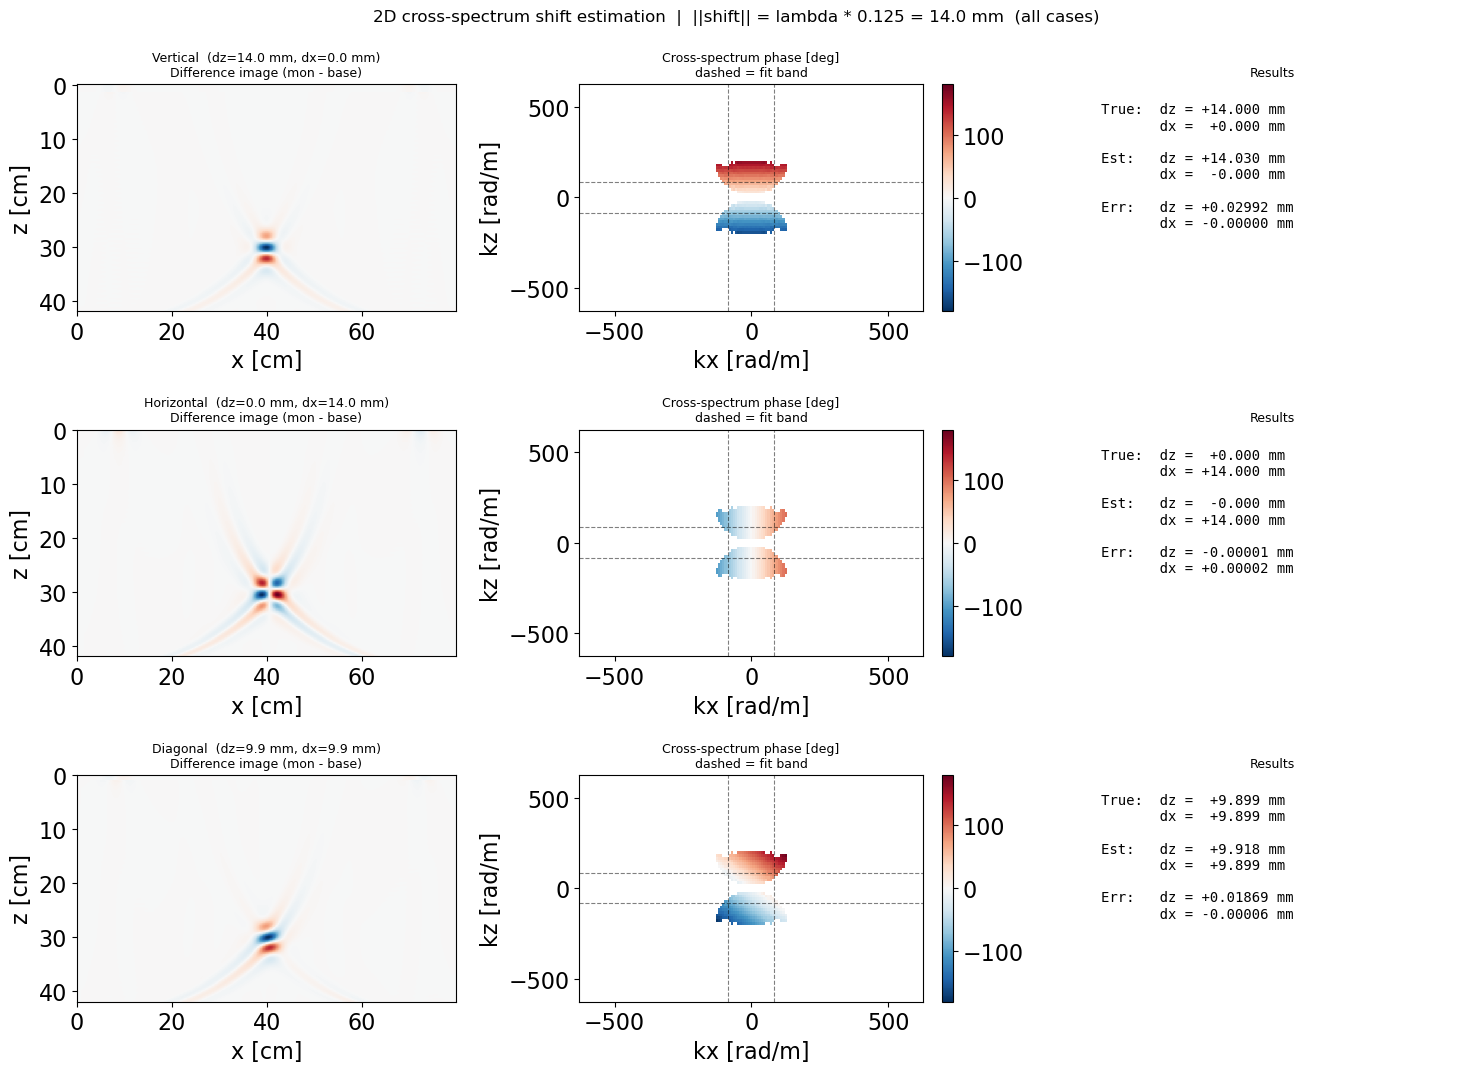

In [26]:
dz_mig = z_mig[1] - z_mig[0]
dx_mig = x_b[1]   - x_b[0]

kz_c = 2 * np.pi / lam
sf   = 1/8

cases = [
    ('Vertical',   sf * lam,              0.0                  ),
    ('Horizontal', 0.0,                   sf * lam             ),
    ('Diagonal',   sf * lam / np.sqrt(2), sf * lam / np.sqrt(2)),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle(
    f'2D cross-spectrum shift estimation  |  '
    f'||shift|| = lambda * {sf} = {sf * lam * 1e3:.1f} mm  (all cases)',
    fontsize=12
)

for row, (name, true_dz, true_dx) in enumerate(cases):

    mon = nd_shift(mig_v_base, (true_dz / dz_mig, true_dx / dx_mig), order=3)

    dz_est, dx_est, XS, kz_ax, kx_ax = estimate_shift_2d(
        mig_v_base, mon, dz_mig, dx_mig, kz_c
    )

    XS_s     = np.fft.fftshift(XS)
    kz_s     = np.fft.fftshift(kz_ax)
    kx_s     = np.fft.fftshift(kx_ax)
    energy   = np.abs(XS_s)
    phi_show = np.where(energy > 0.05 * energy.max(),
                        np.degrees(np.angle(XS_s)), np.nan)

    # Col 0: difference image
    ax   = axes[row, 0]
    diff = mon - mig_v_base
    vmax = np.max(np.abs(diff))
    ax.pcolormesh(x_b * 100, z_mig * 100, diff,
                  cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_title(
        f'{name}  (dz={true_dz*1e3:.1f} mm, dx={true_dx*1e3:.1f} mm)\n'
        'Difference image (mon - base)', fontsize=9
    )
    ax.set_xlabel('x [cm]');  ax.set_ylabel('z [cm]')
    ax.invert_yaxis()

    # Col 1: cross-spectrum phase
    ax2 = axes[row, 1]
    im2 = ax2.pcolormesh(kx_s, kz_s, phi_show,
                         cmap='RdBu_r', vmin=-180, vmax=180, shading='auto')
    klim = 1.5 * kz_c
    for sgn in [-1, 1]:
        ax2.axhline(sgn * klim, color='k', lw=0.8, ls='--', alpha=0.5)
        ax2.axvline(sgn * klim, color='k', lw=0.8, ls='--', alpha=0.5)
    ax2.set_title('Cross-spectrum phase [deg]\ndashed = fit band', fontsize=9)
    ax2.set_xlabel('kx [rad/m]');  ax2.set_ylabel('kz [rad/m]')
    ax2.set_xlim(kx_s.min() / 4, kx_s.max() / 4)
    ax2.set_ylim(kz_s.min() / 4, kz_s.max() / 4)
    plt.colorbar(im2, ax=ax2, fraction=0.046)

    # Col 2: results
    ax3 = axes[row, 2]
    ax3.axis('off')
    txt = (
        f'True:  dz = {true_dz * 1e3:+7.3f} mm\n'
        f'       dx = {true_dx * 1e3:+7.3f} mm\n\n'
        f'Est:   dz = {dz_est  * 1e3:+7.3f} mm\n'
        f'       dx = {dx_est  * 1e3:+7.3f} mm\n\n'
        f'Err:   dz = {(dz_est - true_dz) * 1e3:+.5f} mm\n'
        f'       dx = {(dx_est - true_dx) * 1e3:+.5f} mm'
    )
    ax3.text(0.05, 0.92, txt, transform=ax3.transAxes,
             fontsize=10, family='monospace', verticalalignment='top')
    ax3.set_title('Results', fontsize=9)

plt.tight_layout()
plt.show()

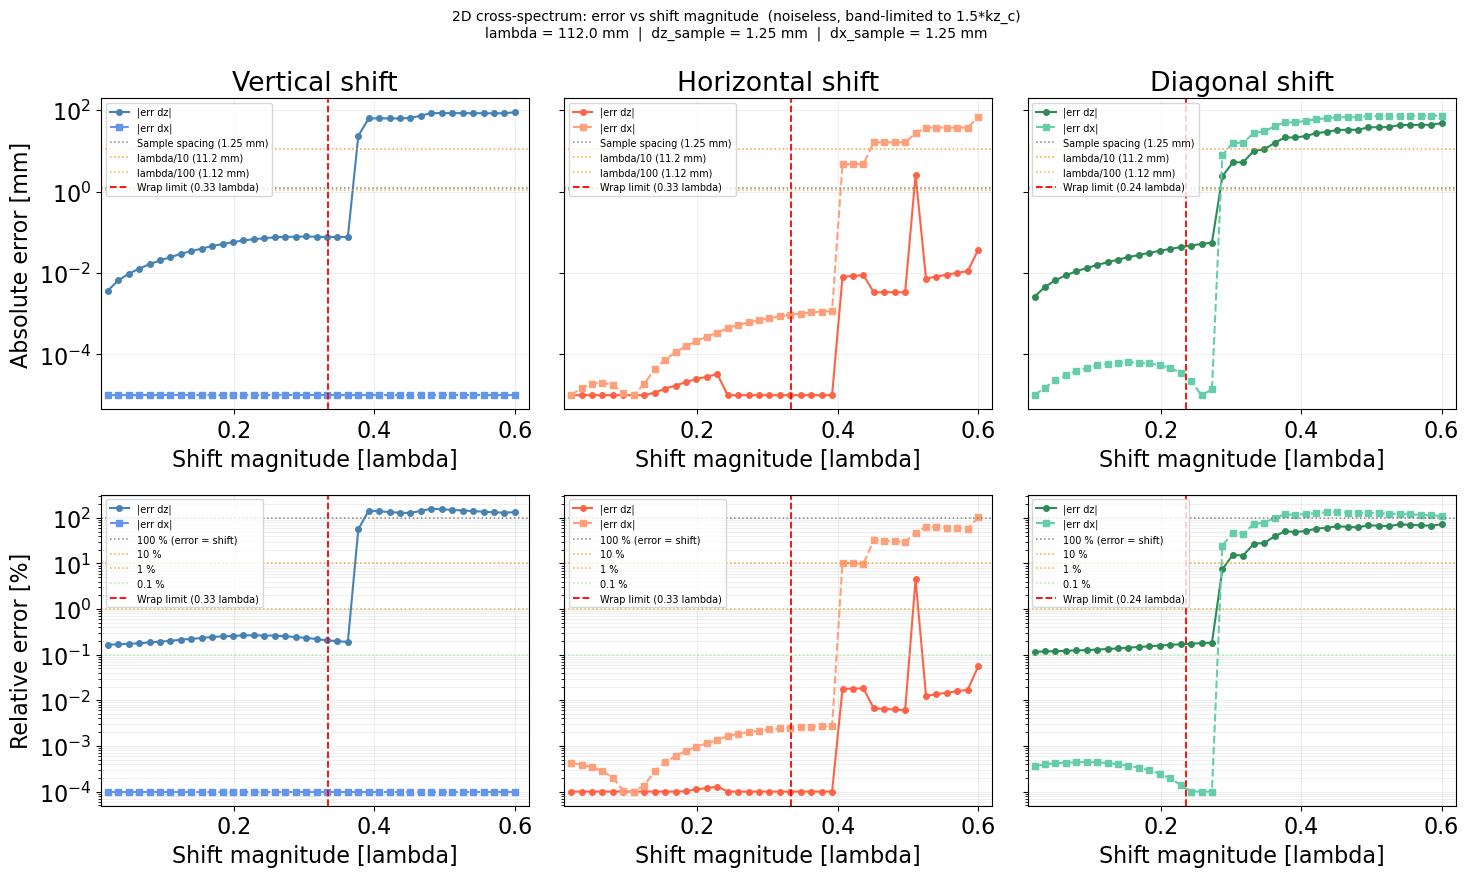

In [ ]:
# =============================================================================
# 2D cross-spectrum estimator: error vs shift magnitude
# Row 0: absolute error |est - true| [mm]
# Row 1: relative error |est - true| / ||true shift||  [%]
#         normalised by the total applied shift magnitude so that small and
#         large shifts are on a comparable footing.
# =============================================================================

 
shift_fracs = np.linspace(0.02, 0.60, 40)

case_defs = [
    ('Vertical',
     lambda s: (s * lam,              0.0              ),
     1.0 / 3.0,
     'steelblue', 'cornflowerblue'),
    ('Horizontal',
     lambda s: (0.0,                  s * lam          ),
     1.0 / 3.0,
     'tomato', 'lightsalmon'),
    ('Diagonal',
     lambda s: (s * lam / np.sqrt(2), s * lam / np.sqrt(2)),
     1.0 / (3.0 * np.sqrt(2)),
     'seagreen', 'mediumaquamarine'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey='row')
fig.suptitle(
    f'2D cross-spectrum: error vs shift magnitude  '
    f'(noiseless, band-limited to 1.5*kz_c)\n'
    f'lambda = {lam*1e3:.1f} mm  |  '
    f'dz_sample = {dz_mig*1e3:.2f} mm  |  '
    f'dx_sample = {dx_mig*1e3:.2f} mm',
    fontsize=10
)

for col, (name, shift_fn, wrap_lim, col_z, col_x) in enumerate(case_defs):
    ax_abs = axes[0, col]
    ax_rel = axes[1, col]

    err_z_abs, err_x_abs = [], []
    err_z_rel, err_x_rel = [], []

    for frac in shift_fracs:
        true_dz, true_dx = shift_fn(frac)
        norm_mm = frac * lam * 1e3          # total shift magnitude [mm]

        mon = nd_shift(mig_v_base,
                       (true_dz / dz_mig, true_dx / dx_mig), order=3)
        dz_est, dx_est, *_ = estimate_shift_2d(
            mig_v_base, mon, dz_mig, dx_mig, kz_c
        )

        ez = abs(dz_est - true_dz) * 1e3   # mm
        ex = abs(dx_est - true_dx) * 1e3

        err_z_abs.append(max(ez, 1e-5))
        err_x_abs.append(max(ex, 1e-5))
        err_z_rel.append(max(ez / norm_mm * 100, 1e-4))   # percent
        err_x_rel.append(max(ex / norm_mm * 100, 1e-4))

    err_z_abs = np.array(err_z_abs)
    err_x_abs = np.array(err_x_abs)
    err_z_rel = np.array(err_z_rel)
    err_x_rel = np.array(err_x_rel)

    for ax, y_z, y_x, ylabel, ref_lines in [
        (ax_abs, err_z_abs, err_x_abs,
         'Absolute error [mm]',
         [(dz_mig * 1e3,   'dimgray',    f'Sample spacing ({dz_mig*1e3:.2f} mm)'),
          (lam * 1e3 / 10, 'darkorange', f'lambda/10 ({lam*1e3/10:.1f} mm)'),
          (lam * 1e3 / 100,'goldenrod',  f'lambda/100 ({lam*1e3/100:.2f} mm)')]),
        (ax_rel, err_z_rel, err_x_rel,
         'Relative error [%]',
         [(100,   'dimgray',    '100 % (error = shift)'),
          (10,    'darkorange', '10 %'),
          (1,     'goldenrod',  '1 %'),
          (0.1,   'lightgreen', '0.1 %')]),
    ]:
        ax.semilogy(shift_fracs, y_z, '-o',  ms=4, lw=1.5,
                    color=col_z, label='|err dz|')
        ax.semilogy(shift_fracs, y_x, '--s', ms=4, lw=1.5,
                    color=col_x, label='|err dx|')

        for level, color, label in ref_lines:
            ax.axhline(level, color=color, ls=':', lw=1.1, alpha=0.8,
                       label=label)

        ax.axvline(wrap_lim, color='red', ls='--', lw=1.3,
                   label=f'Wrap limit ({wrap_lim:.2f} lambda)')

        ax.set_xlabel('Shift magnitude [lambda]')
        if col == 0:
            ax.set_ylabel(ylabel)
        ax.set_xlim(shift_fracs[0] - 0.01, 0.62)
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.2, which='both')

    ax_abs.set_title(f'{name} shift')

plt.tight_layout()
plt.show()


# gprMax Data

In [28]:
import os, time as _time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

In [ ]:
# Medium
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns ≈ 0.16892
f_c_GHz    = 1.5                              # centre frequency [GHz]
wavelength = v_ice / f_c_GHz                  # m ≈ 0.1126
v_mig      = v_ice / 2                        # exploding-reflector half-velocity [m/ns]
t0_ns      = np.sqrt(2) / f_c_GHz            # Ricker peak delay [ns] ≈ 0.943

# Survey geometry
domain_x   = 4.0
n_traces   = 380
trace_step = 0.01   # m
rx_offset  = 0.1    # m (source-receiver offset in .in file)
x_traces   = (0.1 + rx_offset / 2) + np.arange(n_traces) * trace_step   # midpoints [m]

# Scatterer geometry (shared across all datasets)
x_centre        = domain_x / 2
y_surface       = 0.9                          # air-ice interface [m from bottom]
y_scatterer     = y_surface - wavelength * 6  # cylinder centre [m from bottom]
z_scatterer     = y_surface - y_scatterer     # depth below surface [m] ≈ 0.676
radius_scat     = wavelength / 10             # radius of cylinder (point scatterer approximation) [m] ≈ 0.0028
z_top           = z_scatterer - radius_scat   # depth to cylinder top (first reflection)

separations = np.array([2, 1, 0.5, 0.25, 0.125, 0.0625]) * wavelength
x_s1_all    = np.round(x_centre - wavelength * 3 + separations, 3)
x_s2_all    = np.round(x_centre + wavelength * 3 - separations, 3)
labels      = ['Baseline', '2λ', '1λ', '½λ', '¼λ', '⅛λ', '¹⁄₁₆λ']

# Migration depth grid
z_img = np.linspace(0.0, 0.8, 160)
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]

# # Paths
# STUDY_ROOT = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse_study')

print(f'λ_ice       = {wavelength*1e3:.1f} mm')
print(f'v_ice       = {v_ice:.5f} m/ns,  v_mig = {v_mig:.5f} m/ns')
print(f't0_ns       = {t0_ns:.3f} ns')
print(f'z_scatterer = {z_scatterer:.3f} m  (centre),  z_top = {z_top:.4f} m')
print(f'x_traces    : {x_traces[0]:.3f} → {x_traces[-1]:.3f} m  ({n_traces} traces)')

λ_ice       = 112.6 mm
v_ice       = 0.16891 m/ns,  v_mig = 0.08446 m/ns
t0_ns       = 0.943 ns
z_scatterer = 0.676 m  (centre),  z_top = 0.6644 m
x_traces    : 0.150 → 3.940 m  (380 traces)


In [36]:
separation = np.array([0, 2, 1, 1/2, 1/4, 1/8, 1/16]) * wavelength  # m

x_centre = domain_x / 2
x_scatterer_1 = np.round(x_centre - wavelength * 3 + separation, 3) # 7 locations, scatterer that moves
x_scatterer_2 = np.round(x_centre + wavelength * 3, 3) # 7 locations, scatterer that is fixed

# check if discretisation is sufficient for CFL
dx_required = (v_ice / 4.5) / 10 # 4 GHz is the highest frequency component in the Ricker wavelet
if 0.002 < dx_required:
    print(f"Discretisation is sufficiently small")
if radius_scat < dx_required:
    print(f"Scatterer radius is smaller than discretisation")

Discretisation is sufficiently small


In [43]:
rxnumber    = 1
rxcomponent = 'Ez'

output_background, dt = get_output_data(
    'timelapse_study/background/background_merged.out', rxnumber, rxcomponent
)

output_baseline, _ = get_output_data(
    'timelapse_study/baseline/baseline_merged.out', rxnumber, rxcomponent
)

_paths = [
    'timelapse_study/baseline/baseline_merged.out',
    'timelapse_study/shift_2lambda/resolution_2lambda_merged.out',
    'timelapse_study/shift_1lambda/resolution_1lambda_merged.out',
    'timelapse_study/shift_0p5lambda/resolution_0p5lambda_merged.out',
    'timelapse_study/shift_0p25lambda/resolution_0p25lambda_merged.out',
    'timelapse_study/shift_0p125lambda/resolution_0p125lambda_merged.out',
    'timelapse_study/shift_0p0625lambda/resolution_0p0625lambda_merged.out',
]
raw_outputs      = [get_output_data(p, rxnumber, rxcomponent)[0] for p in _paths]
outputs_static   = [r - output_background for r in raw_outputs]      # background-subtracted

dt_ns   = dt * 1e9
n_t     = outputs_static[0].shape[0]
time_ns = np.arange(n_t) * dt_ns

# Convenience lists for the visualisation cells below
data_pre = [('Background', output_background)] + list(zip(labels, raw_outputs))
data_static = list(zip(labels, outputs_static))
labels_all = list(labels)           # all 7 labels (Baseline + 6 shifts)
labels = labels[1:]

print(f'dt = {dt_ns:.6f} ns,  n_t = {n_t},  t_max = {time_ns[-1]:.2f} ns')
print(f'Data shape (n_t × n_tr): {outputs_static[0].shape}  ({n_t} time samples × {n_traces} traces)')

dt = 0.004717 ns,  n_t = 4241,  t_max = 20.00 ns
Data shape (n_t × n_tr): (4241, 380)  (4241 time samples × 380 traces)


In [32]:
# ── Taper & t0-shift parameters ───────────────────────────────────────────────
taper_end_ns   = 14.0   # cosine ramp onset [ns]: zeros hyperbola tails beyond this time
taper_decay_ns = 1.0    # exponential decay time constant [ns]: de-emphasises late arrivals
ANGLE_AP       = 40     # Kirchhoff aperture half-angle [degrees]

# ── Functions ─────────────────────────────────────────────────────────────────
def make_end_taper(n_samples, taper_samples):
    """Unity everywhere, then half-cosine 1→0 over the last `taper_samples`."""
    win = np.ones(n_samples)
    if taper_samples > 0:
        ramp = 0.5 * (1 + np.cos(np.pi * np.arange(taper_samples) / taper_samples))
        win[-taper_samples:] = ramp
    return win

def make_decay_taper(time_ns, tau_ns):
    """Exponential decay starting at 1.0 (t=0) with time constant tau_ns."""
    return np.exp(-time_ns / tau_ns)

def preprocess(data_nt_ntr, dt_ns, t0_ns, time_ns):
    """
    Prepare a B-scan for Kirchhoff migration.
    Input:  data_nt_ntr  (n_t, n_tr)  — background-subtracted B-scan
    Returns tapered (n_tr, n_t) and t0-shifted (n_tr, n_t) arrays.
    """
    bscan   = data_nt_ntr.T.copy()                              # → (n_tr, n_t)
    n_t     = bscan.shape[1]
    w_end   = make_end_taper(n_t, int(round(taper_end_ns / dt_ns)))
    w_decay = make_decay_taper(time_ns, taper_decay_ns)
    tapered = bscan * (w_end * w_decay)[np.newaxis, :]
    t0_samp = int(round(t0_ns / dt_ns))
    shifted = np.roll(tapered, -t0_samp, axis=1)
    shifted[:, -t0_samp:] = 0.0
    return tapered, shifted

In [33]:
# ── Gazdag phase-shift migration on all 7 datasets ────────────────────────────────
migrated_gz = {}

for label, raw in zip(labels_all, outputs_static):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Gazdag ...', flush=True)
    t0 = _time.perf_counter()
    img = gazdag_migration(
        shifted.T,       # (n_t, n_tr) — time first
        x_traces, time_ns, z_img, v_ice
    )
    print(f'  Done in {_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated_gz[label] = img


[Baseline] Running Gazdag ...
  nx=380 -> nx_pad=1140,  evanescent: 48727/2417940 (2.0%)
  Done in 80.9 s  shape=(160, 380)
[2λ] Running Gazdag ...
  nx=380 -> nx_pad=1140,  evanescent: 48727/2417940 (2.0%)
  Done in 80.1 s  shape=(160, 380)
[1λ] Running Gazdag ...
  nx=380 -> nx_pad=1140,  evanescent: 48727/2417940 (2.0%)
  Done in 80.0 s  shape=(160, 380)
[½λ] Running Gazdag ...
  nx=380 -> nx_pad=1140,  evanescent: 48727/2417940 (2.0%)
  Done in 80.9 s  shape=(160, 380)
[¼λ] Running Gazdag ...
  nx=380 -> nx_pad=1140,  evanescent: 48727/2417940 (2.0%)
  Done in 80.3 s  shape=(160, 380)
[⅛λ] Running Gazdag ...
  nx=380 -> nx_pad=1140,  evanescent: 48727/2417940 (2.0%)
  Done in 80.0 s  shape=(160, 380)
[¹⁄₁₆λ] Running Gazdag ...
  nx=380 -> nx_pad=1140,  evanescent: 48727/2417940 (2.0%)
  Done in 80.8 s  shape=(160, 380)


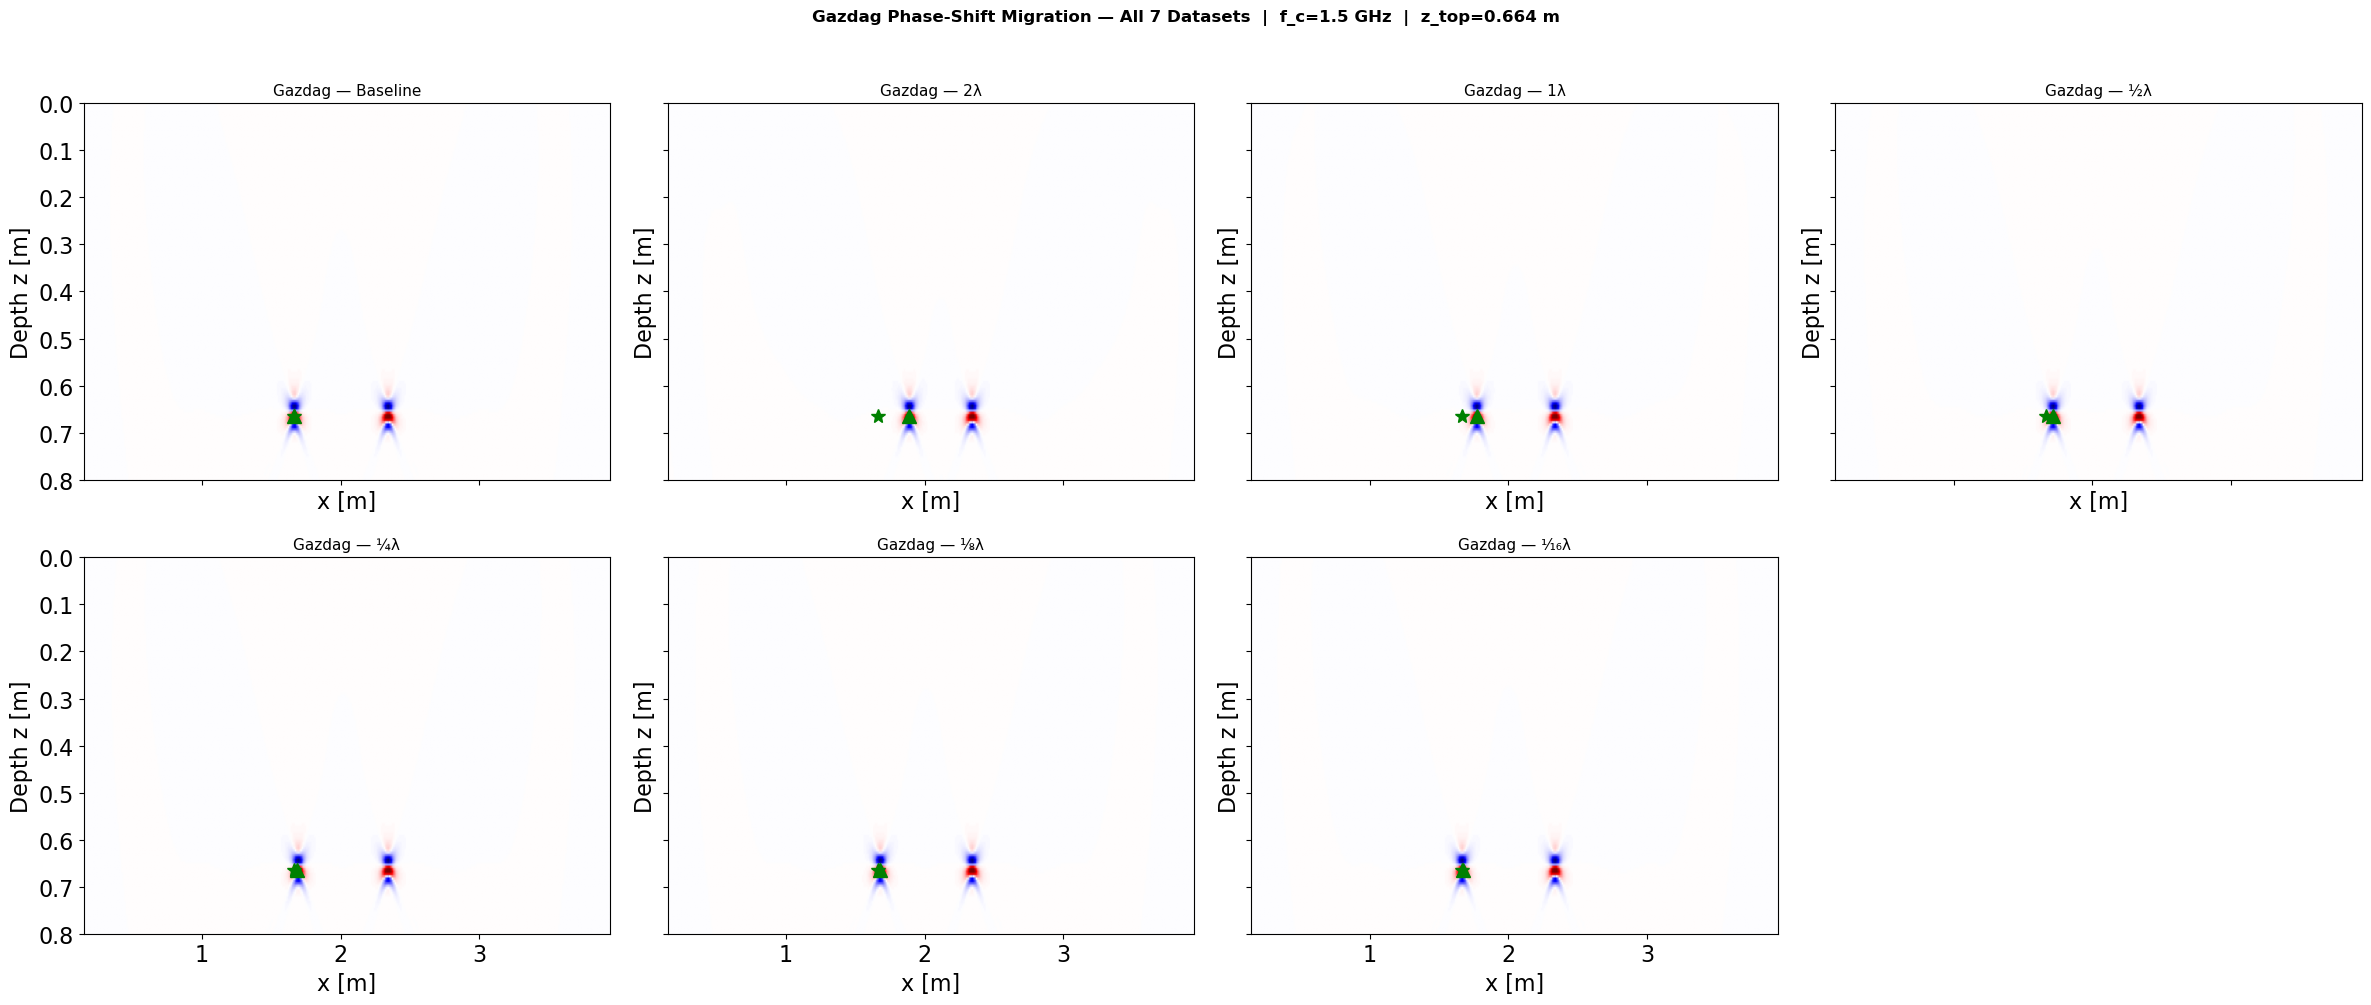

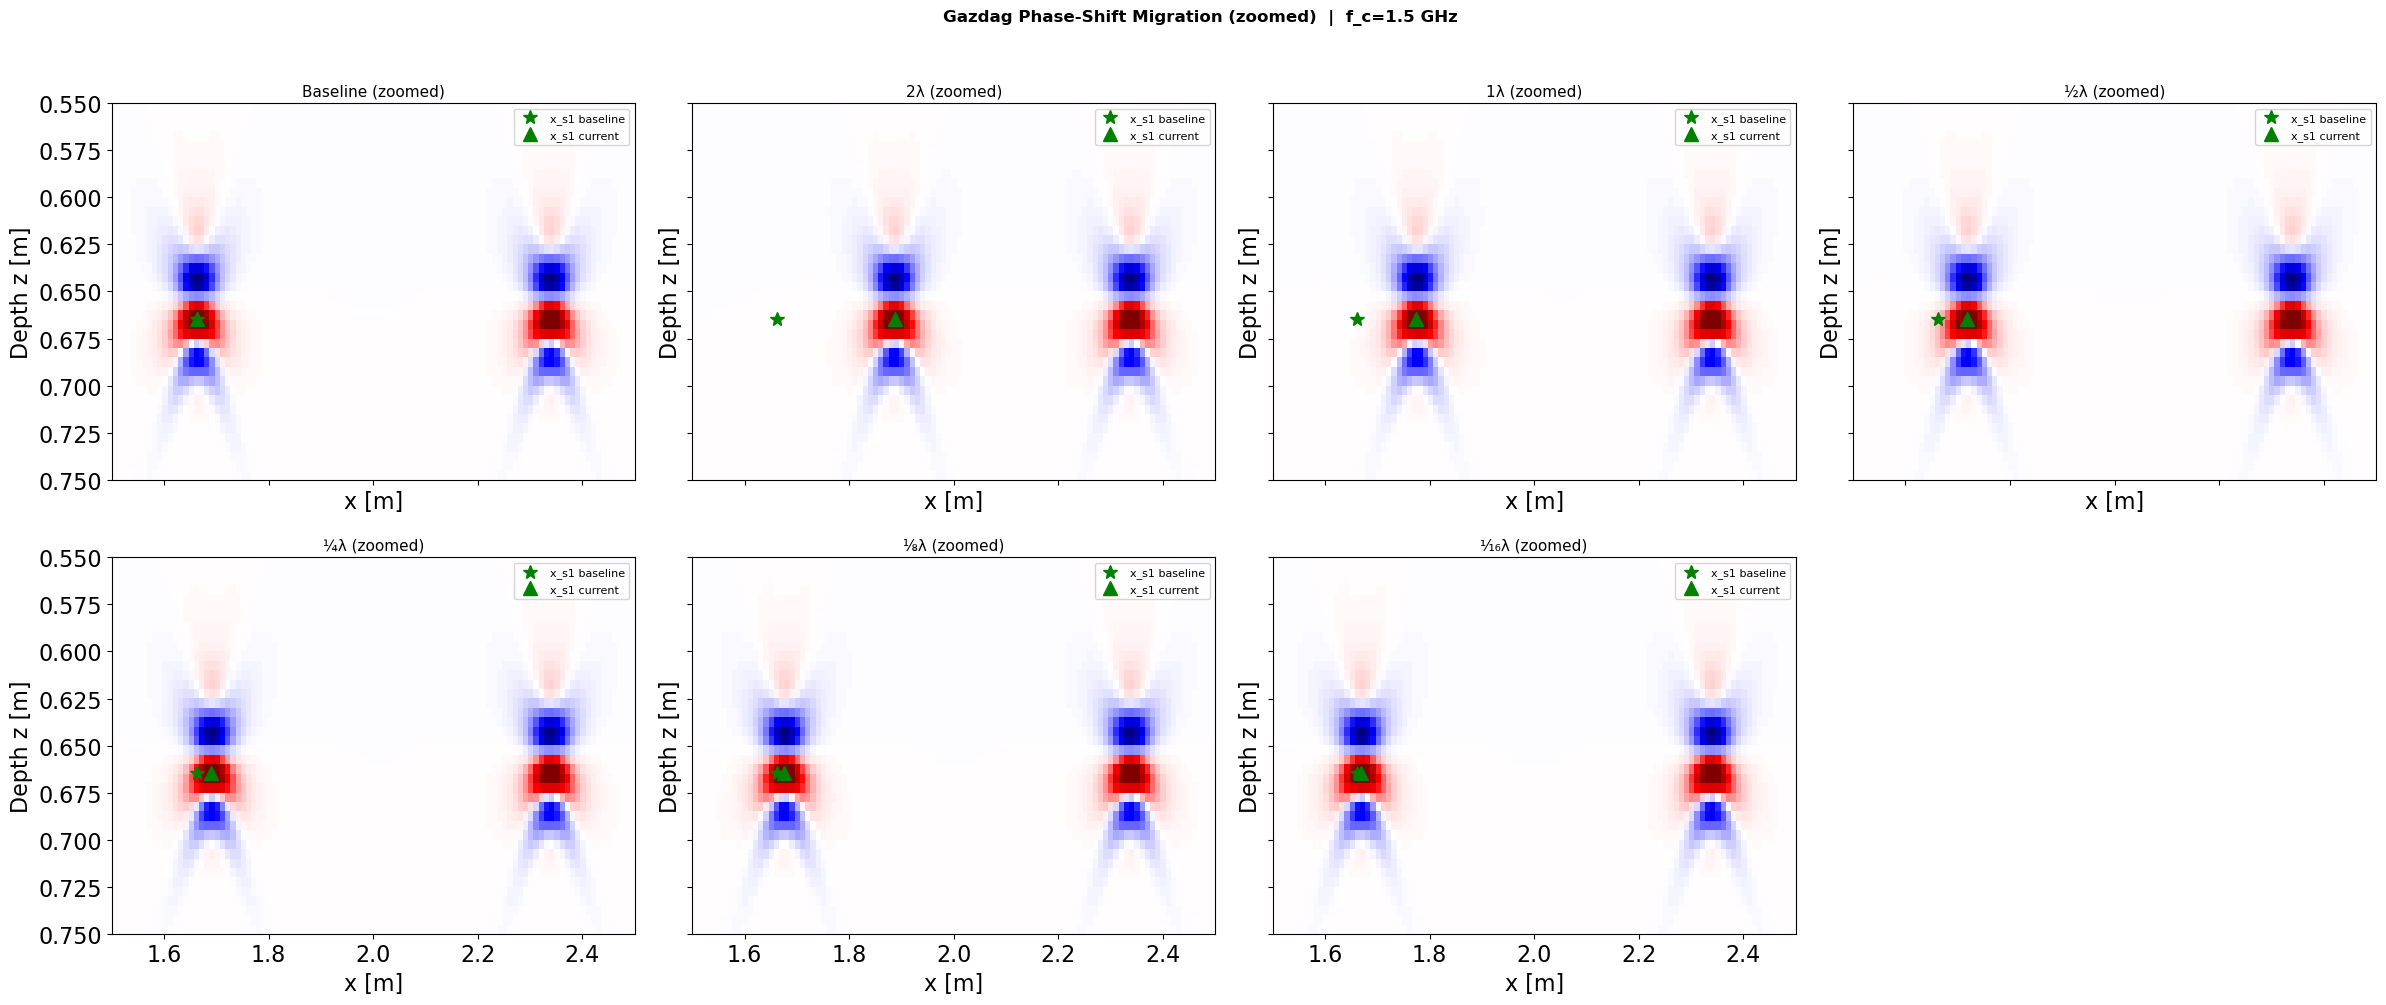

In [40]:
# ── Plot: full extent ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)   # 7 items in 2×4 grid — hide last slot
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated_gz.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0], z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i], z_top, 'g^', ms=10, zorder=5, label='x_s1 current')
    ax.set_title(f'Gazdag — {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

plt.suptitle(
    f'Gazdag Phase-Shift Migration — All 7 Datasets  |  f_c={f_c_GHz} GHz  |  z_top={z_top:.3f} m',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
# plt.savefig(STUDY_ROOT / 'gazdag_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated_gz.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0], z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i], z_top, 'g^', ms=10, zorder=5, label='x_s1 current')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Gazdag Phase-Shift Migration (zoomed)  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
# plt.savefig(STUDY_ROOT / 'gazdag_all_datasets_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


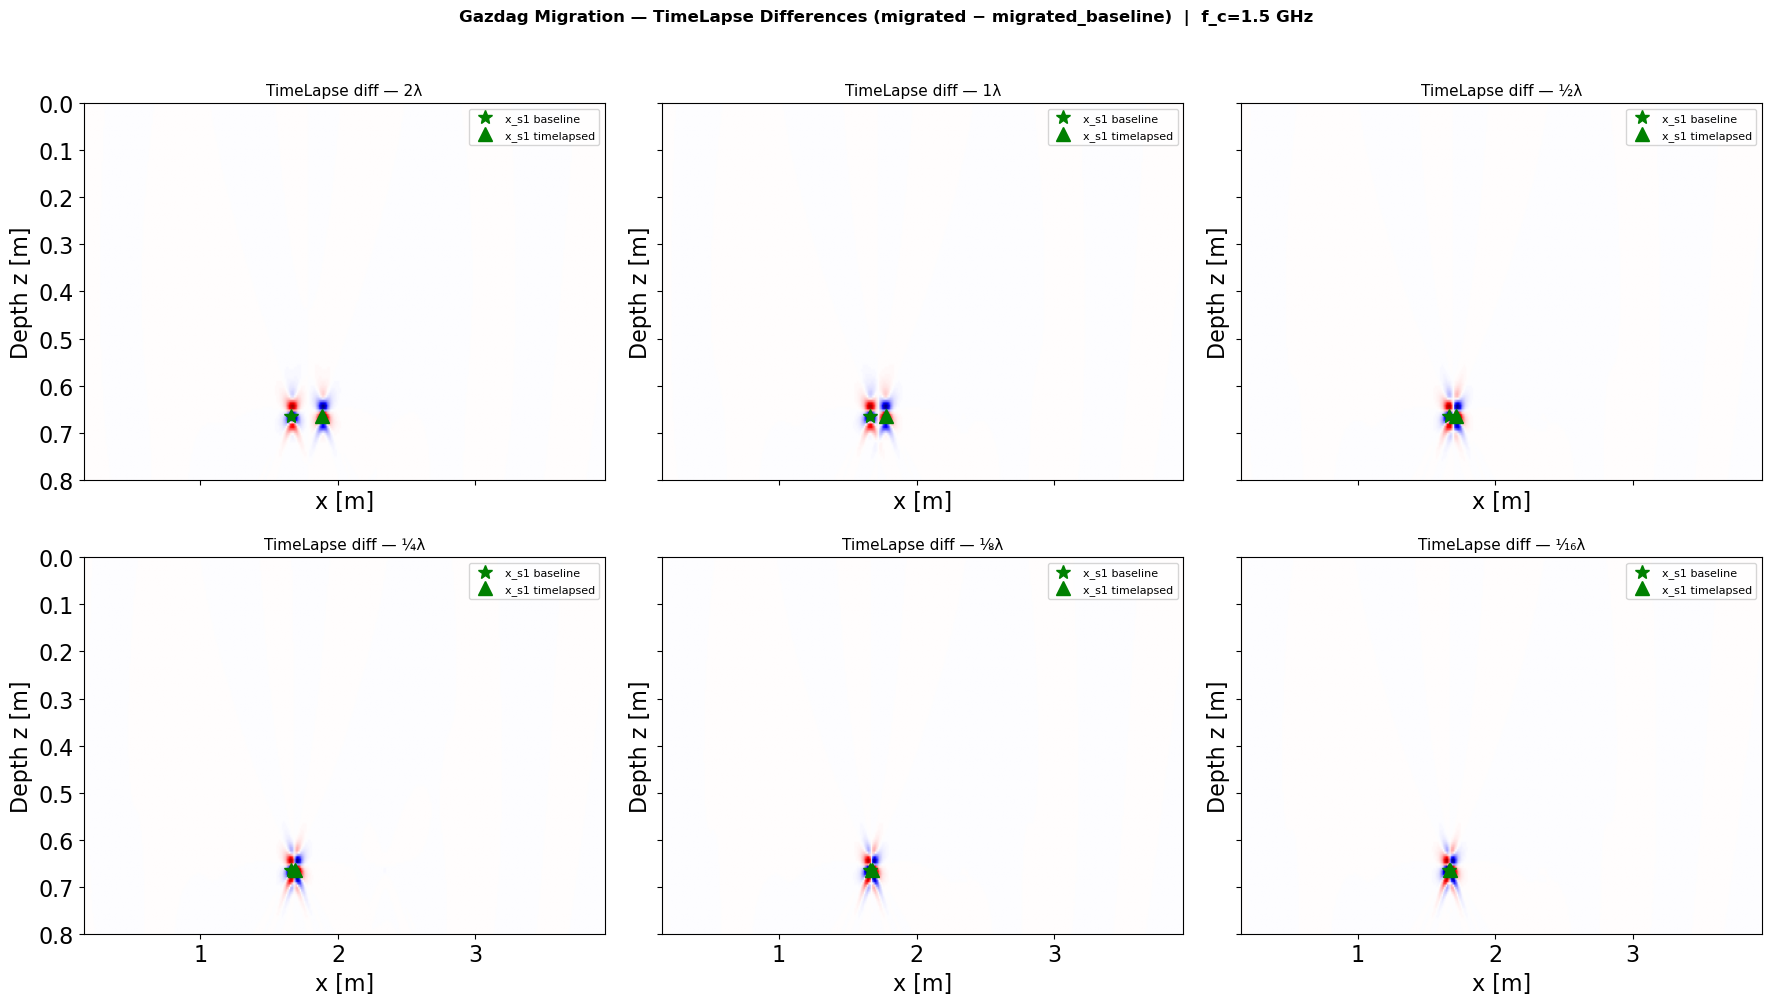

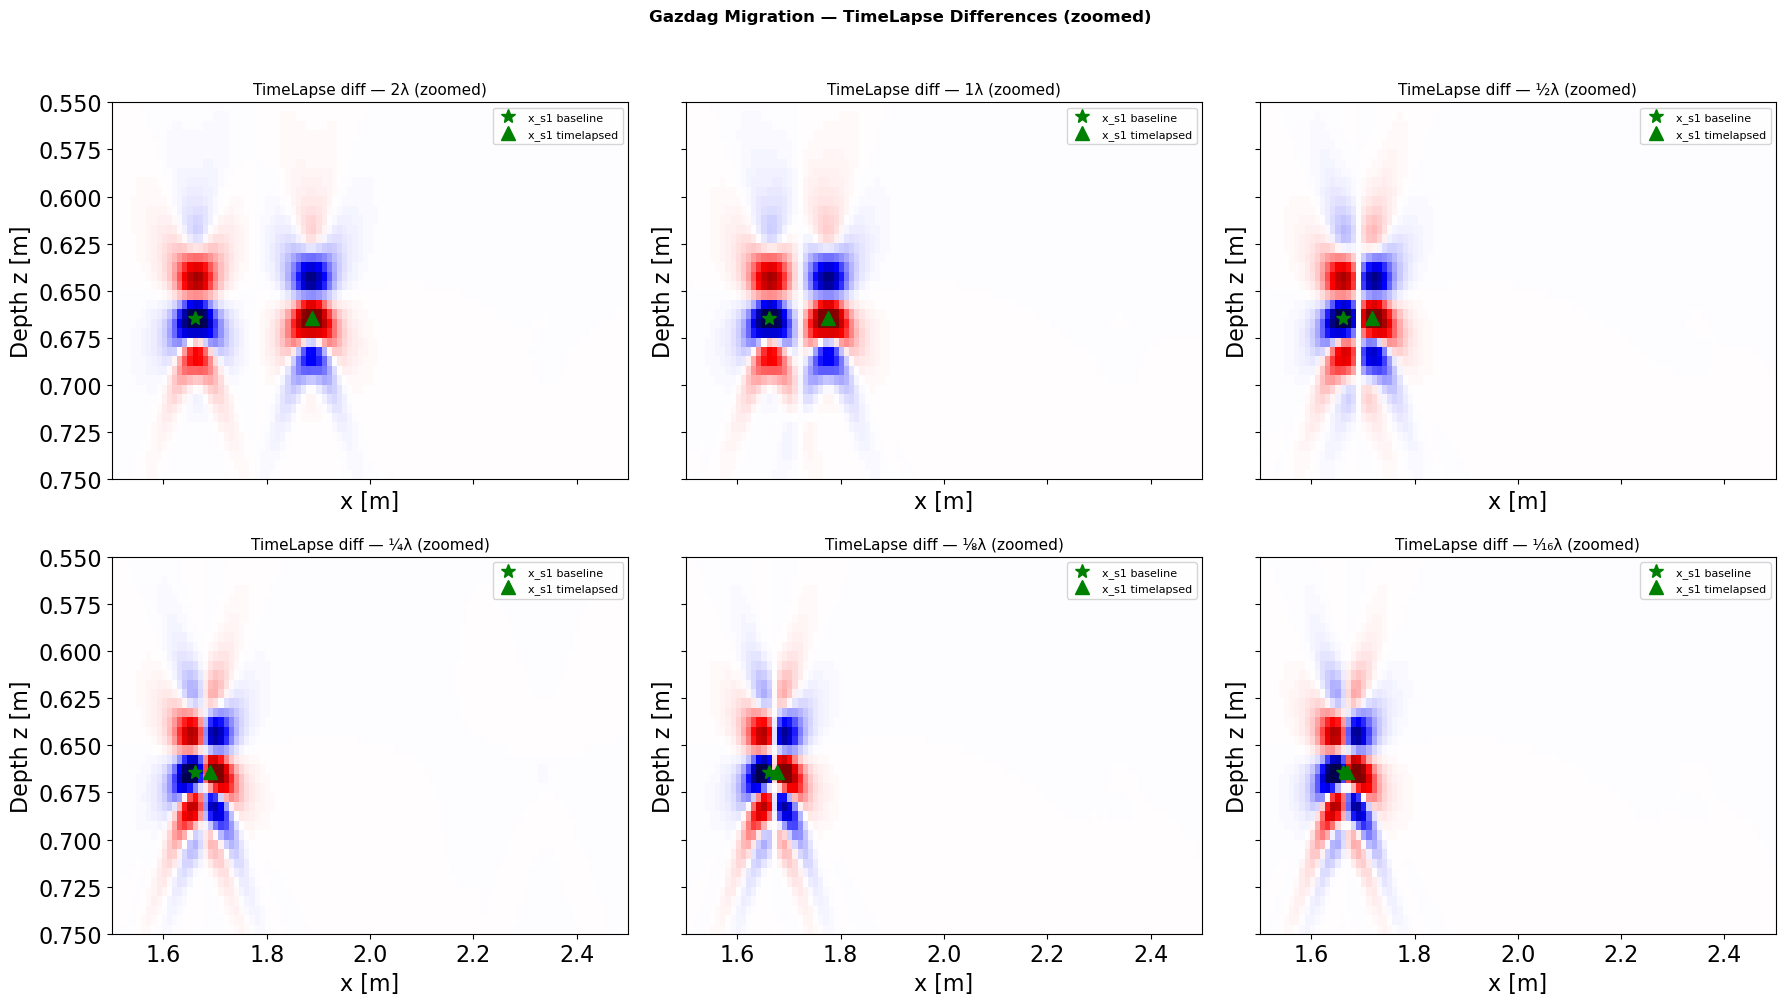

In [44]:
# ── Gazdag timelapse differences (migrated − migrated_baseline) ──────────────────────
migrated_gz_diff = {label: migrated_gz[label] - migrated_gz['Baseline'] for label in labels}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_gz_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_title(f'TimeLapse diff — {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Gazdag Migration — TimeLapse Differences (migrated − migrated_baseline)  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
# plt.savefig(STUDY_ROOT / 'gazdag_timelapse_diff.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Zoomed ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_gz_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'TimeLapse diff — {label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Gazdag Migration — TimeLapse Differences (zoomed)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
# plt.savefig(STUDY_ROOT / 'gazdag_timelapse_diff_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


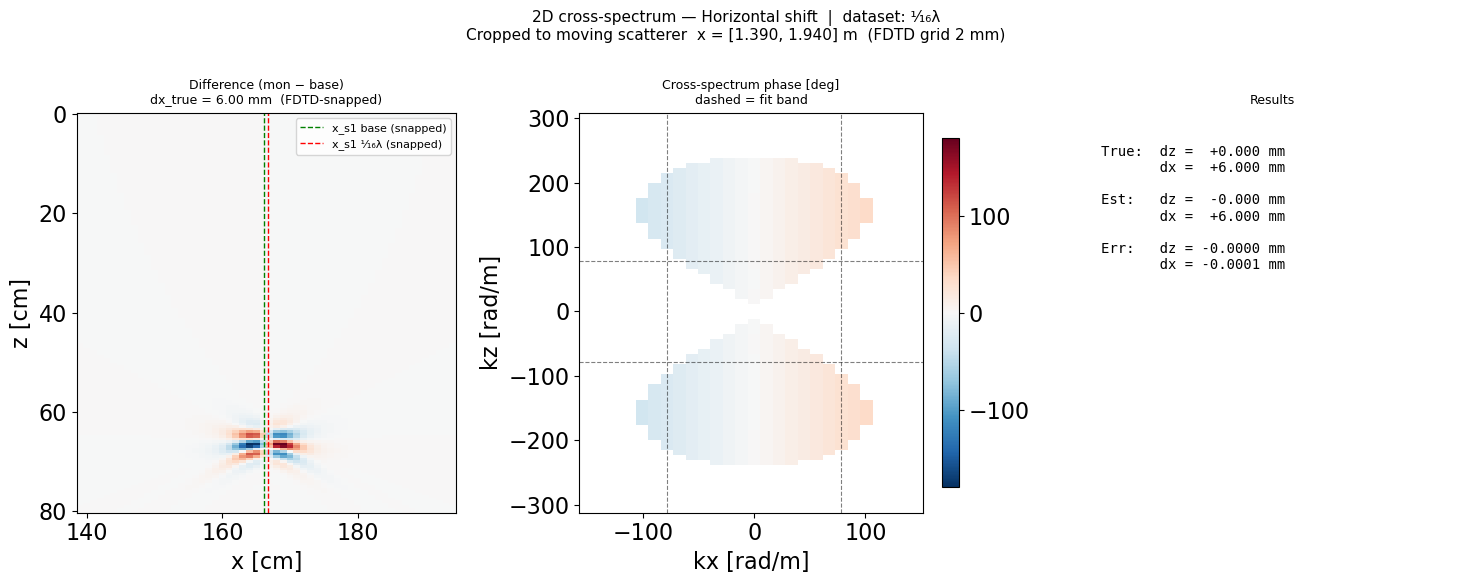

In [111]:
# Dataset and shift index to analyse  (<-- tune)
LABEL     = '¹⁄₁₆λ' #'⅛λ'
SC1_IDX   = 6 #5          # index into x_scatterer_1 for the chosen monitor dataset

dl = 0.002   # gprMax FDTD cell size [m]; positions snap to this grid

# Nominal scatterer positions rounded to mm, then snapped to FDTD grid.
# For 1/16-lambda: nominal 1.669 m = 834.5 cells -> gprMax snaps to 834*0.002 = 1.668 m.
# Using the snapped positions gives the true simulated displacement.
x_s1_base_g = np.round(x_scatterer_1[0]       / dl) * dl
x_s1_mon_g  = np.round(x_scatterer_1[SC1_IDX] / dl) * dl
true_dz = 0.0
true_dx = float(x_s1_mon_g - x_s1_base_g)

dz_mig = z_img[1]    - z_img[0]
dx_mig = x_traces[1] - x_traces[0]
kz_c   = 2 * np.pi / wavelength

# ── Crop to the moving scatterer only ─────────────────────────────────────────
# Two scatterers are present: one moves (+dx), one is fixed at x_centre + 3λ.
# Without cropping the cross-spectrum averages both contributions and the phase
# plane slope converges to dx/2 instead of dx  (one fixed + one moving → average).
x_crop_cen = 0.5 * (x_s1_base_g + x_s1_mon_g)
x_crop_hw  = 2.5 * wavelength          # half-width: fixed scatterer is >4λ away

ix_lo = np.searchsorted(x_traces, x_crop_cen - x_crop_hw)
ix_hi = np.searchsorted(x_traces, x_crop_cen + x_crop_hw)
x_crop = x_traces[ix_lo:ix_hi]

base_crop = migrated_gz['Baseline'][:, ix_lo:ix_hi]
mon_crop  = migrated_gz[LABEL][:,     ix_lo:ix_hi]

# ── Estimate ──────────────────────────────────────────────────────────────────
dz_est, dx_est, XS, kz_ax, kx_ax = estimate_shift_2d(
    base_crop, mon_crop, dz_mig, dx_mig, kz_c
)

XS_s     = np.fft.fftshift(XS)
kz_s     = np.fft.fftshift(kz_ax)
kx_s     = np.fft.fftshift(kx_ax)
energy   = np.abs(XS_s)
phi_show = np.where(energy > 0.01 * energy.max(),
                    np.degrees(np.angle(XS_s)), np.nan)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(
    f'2D cross-spectrum — Horizontal shift  |  dataset: {LABEL}\n'
    f'Cropped to moving scatterer  x = [{x_crop[0]:.3f}, {x_crop[-1]:.3f}] m  '
    f'(FDTD grid {dl*1e3:.0f} mm)',
    fontsize=11
)

# Col 0: difference image (cropped)
ax   = axes[0]
diff = mon_crop - base_crop
vmax = np.max(np.abs(diff))
ax.pcolormesh(x_crop * 100, z_img * 100, diff,
              cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
ax.axvline(x_s1_base_g * 100, color='g', ls='--', lw=1, label='x_s1 base (snapped)')
ax.axvline(x_s1_mon_g  * 100, color='r', ls='--', lw=1, label=f'x_s1 {LABEL} (snapped)')
ax.set_title(f'Difference (mon − base)\ndx_true = {true_dx*1e3:.2f} mm  (FDTD-snapped)', fontsize=9)
ax.set_xlabel('x [cm]');  ax.set_ylabel('z [cm]')
ax.invert_yaxis();  ax.legend(fontsize=8)

# Col 1: cross-spectrum phase (cropped patch)
ax2 = axes[1]
im2 = ax2.pcolormesh(kx_s, kz_s, phi_show,
                     cmap='RdBu_r', vmin=-180, vmax=180, shading='auto')
klim = 1.4 * kz_c
for sgn in [-1, 1]:
    ax2.axhline(sgn * klim, color='k', lw=0.8, ls='--', alpha=0.5)
    ax2.axvline(sgn * klim, color='k', lw=0.8, ls='--', alpha=0.5)
ax2.set_title('Cross-spectrum phase [deg]\ndashed = fit band', fontsize=9)
ax2.set_xlabel('kx [rad/m]');  ax2.set_ylabel('kz [rad/m]')
ax2.set_xlim(kx_s.min() / 2, kx_s.max() / 2)
ax2.set_ylim(kz_s.min() / 2, kz_s.max() / 2)
plt.colorbar(im2, ax=ax2, fraction=0.046)

# Col 2: results
ax3 = axes[2]
ax3.axis('off')
txt = (
    f'True:  dz = {true_dz * 1e3:+7.3f} mm\n'
    f'       dx = {true_dx * 1e3:+7.3f} mm\n\n'
    f'Est:   dz = {dz_est  * 1e3:+7.3f} mm\n'
    f'       dx = {dx_est  * 1e3:+7.3f} mm\n\n'
    f'Err:   dz = {(dz_est - true_dz) * 1e3:+.4f} mm\n'
    f'       dx = {(dx_est - true_dx) * 1e3:+.4f} mm'
)
ax3.text(0.05, 0.92, txt, transform=ax3.transAxes,
         fontsize=10, family='monospace', verticalalignment='top')
ax3.set_title('Results', fontsize=9)

plt.tight_layout()
plt.show()
